B345_S5 SimpleCNNSmall
torch.Size([3200, 1, 200, 200])
torch.Size([10000, 1, 11, 11])
torch.Size([10000, 1, 11, 11])


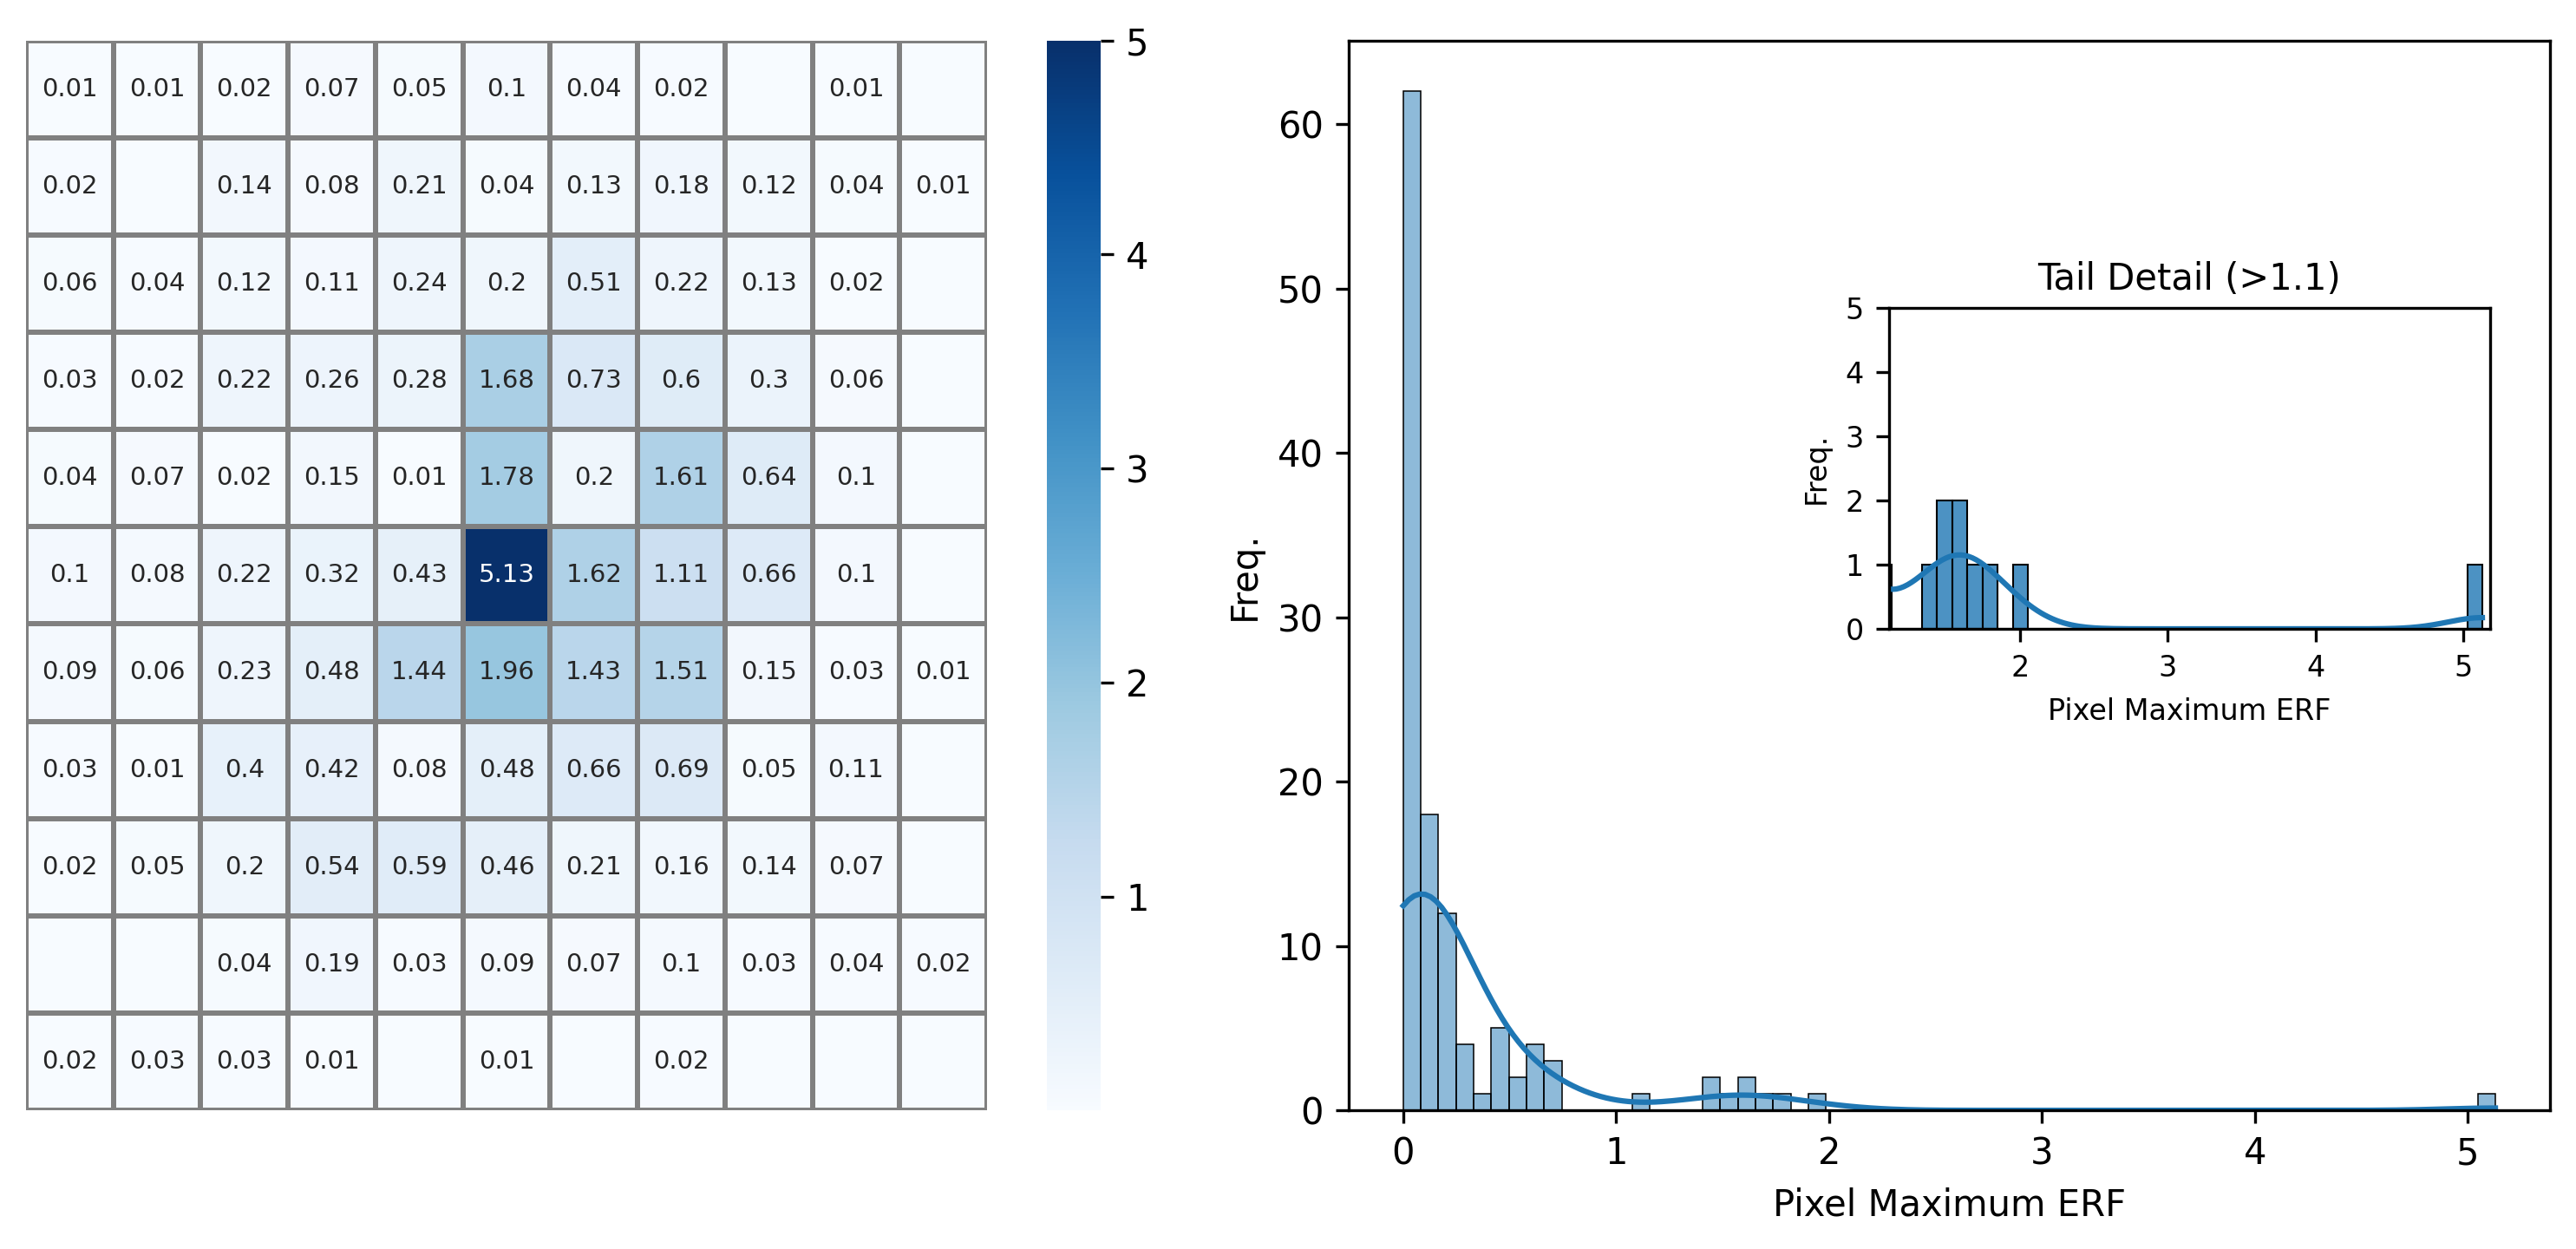

In [19]:
import os
import re

import numpy as np
import torch
from einops import rearrange

from dataloader import LifeGameDataset
import model_conv

s = r"D:\Internship\bimsa\result\predictor_life_simple\2026-03-11_13-48-11_small_3_layer_seq_cnn__200-200-B345_S5\best_simple_life_SimpleCNNSmall_0.1.0.pth"

p = re.compile(r".*?\\(?P<date>\d{4}(-\d\d){2})_(\d\d-){2}\d\d_.*?__(?P<n1>\d+)-(?P<n2>\d+)-(?P<rule>B\d*_S\d*V?)\\best_simple_life_(?P<model>.*?)_\d.*?\.pth")
match_dict = p.match(s).groupdict()
rule_str, model_cls = match_dict["rule"], match_dict["model"]

d = f"./datasets/200-200-{rule_str}"

print(rule_str, model_cls)

model = getattr(model_conv, model_cls)()
model.train()
model.load_state_dict(torch.load(s, map_location=torch.device('cuda')))
model.cuda()

all_files = [os.path.join(d, f) for f in os.listdir(d) if f.endswith('.npy')]
all_files.sort()  # Ensure deterministic split
test_files = all_files[::5]
file_list = [i for i in all_files if i not in test_files]

dataset = LifeGameDataset(file_list=file_list)
data = np.concatenate(dataset.arr_list, axis=0).reshape(-1, 1, 200, 200)

input_original_tensors = torch.tensor(data).float().requires_grad_(False)

print(input_original_tensors.shape)
input_tensors = rearrange(torch.nn.Unfold(kernel_size=(11, 11), padding=0, stride=40)(input_original_tensors),
                          "n (a b) l -> (n l) 1 a b", a=11, b=11)[:10000].detach().clone().requires_grad_(True)
print(input_tensors.shape)

out = model(input_tensors.cuda())
*_, row, col = out.shape
row, col
grad = torch.zeros_like(out)
grad[0, 0, row//2, col//2] = 1

out.backward(gradient=grad)
print(input_tensors.grad.shape)
grad_abs = input_tensors.grad.detach().abs().clone()

res_max = torch.max(grad_abs.cpu(), dim=0)[0][0].numpy()

import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 4.9), dpi=300)
# plt.suptitle(f"Maximum Absolute Pixel Effective Respective Fields of {model.__class__.__name__}\ntrained on {rule_str.replace('_', '/')} Data ({input_tensors.shape[0]} in-distribution samples)")

ax1 = plt.subplot(1, 2, 1)
annot_matrix = np.where(np.abs(res_max) >= 0.01, np.round(res_max, 2), '')
sns.heatmap(res_max, cmap="Blues", annot=annot_matrix, fmt='', ax=ax1, vmax=5, linewidths=1, linecolor="gray", annot_kws={"size": 7})
ax1.set_xticks([]); ax1.set_yticks([])

ax2 = plt.subplot(1, 2, 2)
sns.histplot(res_max.flatten(), kde=True, ax=ax2)
ax2.set_xlabel("Pixel Maximum ERF"); ax2.set_ylabel("Freq.")

ax_inset = ax2.inset_axes([0.45, 0.45, 0.5, 0.3])  # 右上角位置

# 绘制相同数据的局部放大（右侧长尾）
sns.histplot(res_max.flatten(), kde=True, ax=ax_inset, 
             alpha=0.8, bins=50, edgecolor='black', linewidth=0.5)

# 设置放大范围：根据你的数据调整这两个阈值
th = res_max.max()*0.2 + res_max.mean() * 0.3
ax_inset.set_xlim(th, res_max.max()*1.01)  # 只看大于threshold的部分
ax_inset.set_ylim(0, 5)  # 根据实际低频区域调整y轴上限

# 子图美化
ax_inset.set_title(f'Tail Detail (>{th:.2g})', fontsize=10, pad=5)
ax_inset.set_xlabel('Pixel Maximum ERF', fontsize=8)
ax_inset.set_ylabel('Freq.', fontsize=8)
ax_inset.tick_params(labelsize=8)
# ax_inset.patch.set_facecolor("#d2e4ff")  # 淡红背景突出显示
# ax_inset.spines['top'].set_color('darkred')
# ax_inset.spines['right'].set_color('darkred')

# 添加连接线（自动高亮主图中被放大的区域）
# ax2.indicate_inset_zoom(ax_inset, linewidth=1, alpha=0.5)

# 可选：在主图中添加半透明矩形标记被放大区域
# ax2.axvspan(threshold, res_max.max(), alpha=0.1, zorder=0)

plt.tight_layout()
plt.show()

fig.savefig(f"./{model.__class__.__name__}_{rule_str}.pdf", transparent=True, dpi=400, format="pdf")

In [ ]:
s = r"..\result\predictor_life_simple\2026-02-10_17-25-43_small_4_layer_seq_cnn__200-200-B3678_S34678\best_simple_life_SimpleCNNSmall_4Layer_0.1.0.pth"

p = re.compile(r".*?\\(?P<date>\d{4}(-\d\d){2})_(\d\d-){2}\d\d_.*?__(?P<n1>\d+)-(?P<n2>\d+)-(?P<rule>B\d*_S\d*V?)\\best_simple_life_(?P<model>.*?)_\d.*?\.pth")

p.match(s)

<re.Match object; span=(0, 144), match='..\\result\\predictor_life_simple\\2026-02-10_17->

In [ ]:
from pathlib import Path

def get_pth_list(folder_path):
    path = Path(folder_path)
    # 返回生成器，可以转为list
    pth_files = list(filter(lambda x: "old_history" not in str(x), path.rglob("*.pth")))
    
    # 按文件名排序
    pth_files.sort(key=lambda x: x.name)
    
    print(f"Found {len(pth_files)} .pth files\nthe first is {pth_files[0].name} at\n{pth_files[0]}")
    
    return pth_files  # 返回列表供后续使用

# 使用
pth_list = get_pth_list("/Users/heruijie/BIMSA/result/predictor_life_simple")

Found 44 .pth files
the first is best_simple_life_SimpleCNNSmall_0.1.0.pth at
/Users/heruijie/BIMSA/result/predictor_life_simple/2026-03-10_10-57-57_small_3_layer_seq_cnn__200-200-B3678_S34678/best_simple_life_SimpleCNNSmall_0.1.0.pth


In [ ]:
import os
import re

import numpy as np
import torch
from einops import rearrange
from pathlib import Path

from dataloader import LifeGameDataset
import model_conv

def get_pth_list(folder_path):
    path = Path(folder_path)
    # 返回生成器，可以转为list
    pth_files = list(filter(lambda x: "old_history" not in str(x), path.rglob("*.pth")))
    
    # 按文件名排序
    pth_files.sort(key=lambda x: x.name)
    
    print(f"Found {len(pth_files)} .pth files\nthe first is {pth_files[0].name} at\n{pth_files[0]}")
    
    return pth_files  # 返回列表供后续使用

def process_erf(s):
    p = re.compile(r".*?/(?P<date>\d{4}(-\d\d){2})_(\d\d-){2}\d\d_.*?__(?P<n1>\d+)-(?P<n2>\d+)-(?P<rule>B\d*_S\d*V?)/best_simple_life_(?P<model>.*?)_\d.*?\.pth")
    match_dict = p.match(s).groupdict()
    rule_str, model_cls = match_dict["rule"], getattr(model_conv, match_dict["model"])

    d = f"./datasets/200-200-{rule_str}"

    print(rule_str, model_cls.__name__)

    model = model_cls()
    model.load_state_dict(torch.load(s, map_location=torch.device('cpu')))

    all_files = [os.path.join(d, f) for f in os.listdir(d) if f.endswith('.npy')]
    all_files.sort()  # Ensure deterministic split
    test_files = all_files[::5]
    file_list = [i for i in all_files if i not in test_files]

    dataset = LifeGameDataset(file_list=file_list)
    data = np.stack(dataset.arr_list, axis=1).reshape(-1, 1, 200, 200)

    input_original_tensors = torch.tensor(data).float().requires_grad_(False)

    print(input_original_tensors.shape)
    input_tensors = rearrange(torch.nn.Unfold(kernel_size=(11, 11), padding=0, stride=40)(input_original_tensors),
                            "n (a b) l -> (n l) 1 a b", a=11, b=11).detach().clone().requires_grad_(True)
    print(input_tensors.shape)

    out = model(input_tensors)
    *_, row, col = out.shape
    row, col
    grad = torch.zeros_like(out)
    grad[0, 0, row//2, col//2] = 1

    out.backward(gradient=grad)
    print(input_tensors.grad.shape)
    grad_abs = input_tensors.grad.abs().clone()

    res_max, res_avg = torch.max(grad_abs, dim=0)[0][0].numpy(), torch.mean(grad_abs, dim=(0, 1)).numpy()

    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(20, 8), dpi=300)
    plt.suptitle(f"Everage and Maximum Effective Respective Fields of {model.__class__.__name__} trained on B3678/S34678 Data")

    ax1 = plt.subplot(1, 2, 1)
    ax1.set_title(r"Maximum Absolute ERF accross 3200 samples")
    annot_matrix = np.where(np.abs(res_max) >= 0.01, np.round(res_max, 2), '')
    sns.heatmap(res_max, cmap="Blues", annot=annot_matrix, fmt='', ax=ax1, vmax=5, linewidths=1, linecolor="gray")
    ax1.set_xticks([]); ax1.set_yticks([])

    ax2 = plt.subplot(1, 2, 2)
    ax2.set_title(r"Average Absolute ERF accross 3200 samples")
    annot_matrix = np.where(np.abs(res_avg) >= 0.01, np.round(res_avg, 2), '')
    sns.heatmap(res_avg, cmap="Blues", annot=annot_matrix, fmt='', ax=ax2, vmax=5, linewidths=1, linecolor="gray")
    ax2.set_xticks([]); ax2.set_yticks([])

